# Word LLM Translation Workflow

- **Purpose:** prepare a styled Word document for downstream LLM translation
- **Input document:** user-supplied `.docx` file placed in the `word_files` subdirectory
- **Source language:** user-defined in this notebook
- **Important:** table content is intentionally omitted in this workflow; this pipeline currently extracts paragraph-based content only

## Notebook 0 — Parse, inspect, and batch DOCX content

This notebook performs the first stage of the workflow:

- verifies the input DOCX file path
- inspects paragraph styles and inline formatting
- extracts paragraph and footnote content into structured elements
- applies light text normalization for downstream translation
- counts tokens for each element
- assigns batch numbers for grouped LLM processing
- saves a metadata-aware JSON checkpoint for the next notebook

### Setup

In [1]:
# define source language

source_language = 'English'

In [2]:
# show docx files in the /word_files subdirectory
import importlib
import workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)

word_dir = workflow_helpers.get_word_files_dir()
docx_files = workflow_helpers.list_docx_files(word_dir)

Found DOCX files:
- custom_word_styles_example.docx
- default_word_styles_example.docx


#### Enter the source Word document you wish to translate here:

In [3]:
docxfilename = 'custom_word_styles_example.docx'

In [4]:
# confirm that the docx file defined above exists
import importlib, workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)
word_dir = workflow_helpers.get_word_files_dir()
docx_path = workflow_helpers.verify_docx_file(docxfilename, word_dir=word_dir)

Confirmed DOCX present: word\word_files\custom_word_styles_example.docx


In [ ]:
# Inspect Word styles in use
# Print Word styles in use in the main body of the docx file
# Footnotes are handled separately below
# Tables are ignored

import importlib, workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)

style_report = workflow_helpers.summarize_docx_styles(docx_path)

──────────────────────────────────────────
Document: word_files\custom_word_styles_example.docx
──────────────────────────────────────────
Total paragraphs: 31
Unique paragraph styles: 6
    19  body
     6  h2
     2  legend
     2  image
     1  h1
     1  quotation

Inline formatting counts:
  bold        : 35
  italic      : 2

Inline formatting examples (up to 10 each):
  bold:
     - self-directed study
     - “big picture”
     - 30 minutes
     - two parts
     - equipped, empowered and excited
     - as you are reading it
     - non-sequential
     - greater understanding
     - Bible
     - pencil
  italic:
     - as you are reading it
     - Image: Old Testament Structure and Timeline
──────────────────────────────────────────


In [6]:
# Detect elements by Word style in main body text
# Attempts image detection, however, image elements are dropped in downstream steps 

from collections import defaultdict
from docx import Document

doc = Document(docx_path)

ns = {
    "w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main",
    "wp": "http://schemas.openxmlformats.org/drawingml/2006/wordprocessingDrawing",
    "a": "http://schemas.openxmlformats.org/drawingml/2006/main",
    "r": "http://schemas.openxmlformats.org/officeDocument/2006/relationships",
}

style_examples = defaultdict(list)

for paragraph in doc.paragraphs:
    style_name = paragraph.style.name if paragraph.style else "Unknown"
    raw_text = paragraph.text or ""
    clean_text = raw_text.strip()

    if len(style_examples[style_name]) >= 5:
        continue

    if clean_text:
        preview = clean_text[:50] + ("..." if len(clean_text) > 50 else "")
        style_examples[style_name].append(preview)
        continue

    # If no visible text, inspect for image metadata
    p_xml = paragraph._p
    docprs = p_xml.findall(".//wp:docPr", ns)
    blips = p_xml.findall(".//a:blip", ns)

    image_label = None

    # Prefer descr, then title, then filename, then docPr name
    for dp in docprs:
        descr = dp.get("descr")
        title = dp.get("title")
        name = dp.get("name")

        if descr:
            image_label = descr
            break
        if title:
            image_label = title
            break
        if name and not image_label:
            image_label = name

    for blip in blips:
        rid = blip.get(f"{{{ns['r']}}}embed")
        if rid and rid in doc.part.rels:
            rel = doc.part.rels[rid]
            image_part = getattr(rel, "target_part", None)
            partname = getattr(image_part, "partname", None)
            if partname:
                filename = str(partname).split("/")[-1]
                image_label = filename
                break

    if image_label:
        preview = f"[IMAGE: {image_label}]"
    else:
        preview = "[EMPTY]"

    style_examples[style_name].append(preview)

print("Paragraph style text previews")
print("──────────────────────────────────────────")

for style_name, examples in style_examples.items():
    print(f"\n{style_name}:")
    for i, preview in enumerate(examples, start=1):
        print(f"  {i}. {preview}")

Paragraph style text previews
──────────────────────────────────────────

h1:
  1. Introduction

h2:
  1. Welcome
  2. The Non-Sequential Reading Approach
  3. Getting Started
  4. The Importance of Daily Reading
  5. The Bible at a Glance

body:
  1. This course is designed for the person that wants ...
  2. This is a self-directed study to assist you in you...
  3. The course consists of two parts: the first covers...
  4. After completing this course, you will be equipped...
  5. Most people that are new to the Bible approach it ...

quotation:
  1. You will need a Bible and a pencil or highlighter.

legend:
  1. Image: Old Testament Structure and Timeline
  2. Image: New Testament Structure and Timeline

image:
  1. [IMAGE: image1.png]
  2. [IMAGE: image2.png]


## Extract elements
- Extracts main body elements, dropping images, tables and blank elements
- Extracts footnote elements, if any

In [7]:
import importlib, workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)

elements, extraction_summary = workflow_helpers.extract_docx_elements(docx_path)

Extracted 28 body elements from DOCX.
Appended 1 footnote elements.
Skipped 3 blank body paragraphs.
Footnote preview:
29. [footnote] Generally, you’ll understand the Bible best in your first language, so feel free to use that translation if it is availa


In [8]:
# Full extraction dataframe for inspection
import pandas as pd

elements_df = pd.DataFrame(elements)
print(elements_df.shape)
display(elements_df.head(15))
display(elements_df.tail(14))

(29, 5)


,element_number,element_type,word_style,text,element_id
0,1,paragraph,h1,Introduction,8633e724fc99
1,2,paragraph,h2,Welcome,2e6212d6aad5
2,3,paragraph,body,This course is designed for the person that wa...,4126aaaf767e
3,4,paragraph,body,This is a **self-directed study** to assist yo...,24ef2f4ac85e
4,5,paragraph,body,The course consists of **two parts**: the firs...,083f0de61472
5,6,paragraph,body,"After completing this course, you will be **eq...",00764d996d76
6,7,paragraph,h2,The Non-Sequential Reading Approach,44e085da6da8
7,8,paragraph,body,Most people that are new to the Bible approach...,0f0419c8c247
8,9,paragraph,body,"However, this often leads to frustration becau...",224d9cd39e1a
9,10,paragraph,h2,Getting Started,f1e071f3c3e5


,element_number,element_type,word_style,text,element_id
15,16,paragraph,body,Read the Bible selection **as quickly as you c...,97f17b1381a8
16,17,paragraph,body,It is important to **read every day**——missing...,3948ff790027
17,18,paragraph,h2,The Bible at a Glance,63ccfcdcd12e
18,19,paragraph,body,The Bible consists of the **Hebrew** and **Gre...,44b22fddd655
19,20,paragraph,body,The **Hebrew** Scriptures contain **39 books**...,f61e7943bb8a
20,21,paragraph,legend,*Image: Old Testament Structure and Timeline*,538cd647d4cd
21,22,paragraph,body,"The **Greek** Scriptures contain **27 books**,...",602232049dbe
22,23,paragraph,legend,Image: New Testament Structure and Timeline,386b209ebaa9
23,24,paragraph,h2,Navigating the Bible: Chapters and Verses,32f4b1db27a0
24,25,paragraph,body,The Bible is **numbered** so that it is easy t...,f19308307b64


In [9]:
# Counts by Word style in extracted elements
style_counts_extracted = elements_df["word_style"].value_counts().sort_index()
print(style_counts_extracted)

word_style
body         18
footnote      1
h1            1
h2            6
legend        2
quotation     1
Name: count, dtype: int64


In [10]:
# Compare extracted counts vs source non-blank paragraph counts
from collections import Counter
from docx import Document

doc = Document(docx_path)

source_nonblank_counts = Counter()
for p in doc.paragraphs:
    style = p.style.name if p.style else "Unknown"
    if (p.text or "").strip():
        source_nonblank_counts[style] += 1

source_nonblank_df = (
    pd.Series(source_nonblank_counts, name="source_nonblank_count")
    .sort_index()
    .to_frame()
)

extracted_counts_df = (
    elements_df["word_style"]
    .value_counts()
    .sort_index()
    .rename("extracted_count")
    .to_frame()
)

compare_df = source_nonblank_df.join(extracted_counts_df, how="outer").fillna(0).astype(int)
display(compare_df)

,source_nonblank_count,extracted_count
body,18,18
footnote,0,1
h1,1,1
h2,6,6
legend,2,2
quotation,1,1


In [11]:
# Paragraph diagnostics

from docx import Document

doc = Document(docx_path)

print("Paragraph-by-paragraph extraction diagnostics")
print("─" * 90)

for i, paragraph in enumerate(doc.paragraphs, start=1):
    style_name = paragraph.style.name if paragraph.style else "Unknown"
    raw_text = paragraph.text or ""
    stripped = raw_text.strip()

    preview = stripped[:60] + ("..." if len(stripped) > 60 else "")
    if not stripped:
        preview = "[BLANK AFTER STRIP]"

    print(f"{i:>2}. {style_name:<12} | chars={len(raw_text):>3} | stripped={len(stripped):>3} | {preview}")

Paragraph-by-paragraph extraction diagnostics
──────────────────────────────────────────────────────────────────────────────────────────
 1. h1           | chars= 12 | stripped= 12 | Introduction
 2. h2           | chars=  7 | stripped=  7 | Welcome
 3. body         | chars=408 | stripped=408 | This course is designed for the person that wants to learn w...
 4. body         | chars=431 | stripped=431 | This is a self-directed study to assist you in your quest fo...
 5. body         | chars=304 | stripped=304 | The course consists of two parts: the first covers the basic...
 6. body         | chars=110 | stripped=110 | After completing this course, you will be equipped, empowere...
 7. h2           | chars= 36 | stripped= 35 | The Non-Sequential Reading Approach
 8. body         | chars=151 | stripped=151 | Most people that are new to the Bible approach it like any o...
 9. body         | chars=488 | stripped=488 | However, this often leads to frustration because a linear re...
10. h2  

In [12]:
# Inspect the last element entry

elements[(len(elements)-1)]

{'element_number': 29,
 'element_type': 'footnote',
 'word_style': 'footnote',
 'text': 'Generally, you’ll understand the Bible best in your first language, so feel free to use that translation if it is available in your native tongue. If you are bilingual, use the language with which you are most comfortable',
 'element_id': '93fb683c746a'}

In [13]:
# Inspect text elements

for el in elements[:5]:
    print(el["text"])

Introduction
Welcome
This course is designed for the person that wants to learn what it means to become or be a follower of Jesus. Many people that seek this knowledge realize that the Bible is where they must look, but have been hampered in their quest for one reason or another (e.g. intimidated by the size of the Bible, don’t know where to begin, tried to read the Bible but couldn’t make sense of it, got discouraged, etc.).
This is a **self-directed study** to assist you in your quest for answers. It is intended to take you rapidly through select books of the Bible to give you a **“big picture”** overview of what it means to be or become a follower of Jesus, and to become familiarized with the Bible——which is the definitive handbook for those who want to follow Jesus. For maximum benefit, plan on spending about **30 minutes** every day for the next few weeks.
The course consists of **two parts**: the first covers the basics and can be completed in two weeks. The second part “digs dee

### Calculate token size and record to schema

In [14]:
# Calculate token sizes for each element
import importlib, workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)
token_summary = workflow_helpers.count_tokens_with_tiktoken(
    elements,
    model_name="gpt-4o",
)

Updated 29 elements with tiktoken counts (model: gpt-4o) | min=1 | median=24 | max=195 | mean=48.7


In [15]:
elements[0]

{'element_number': 1,
 'element_type': 'paragraph',
 'word_style': 'h1',
 'text': 'Introduction',
 'element_id': '8633e724fc99',
 'tokens': 1}

Elements: 29 | min=1 | median=24 | max=195 | mean=48.7


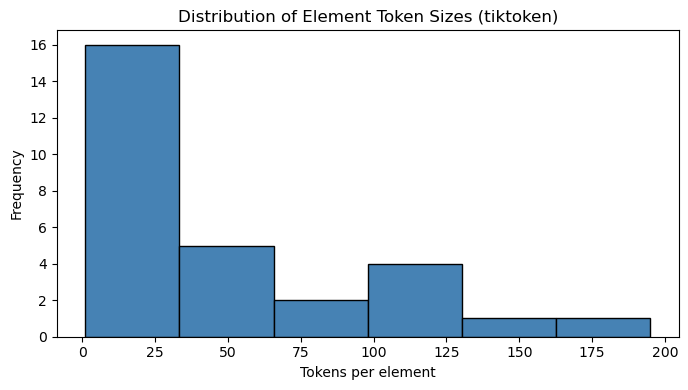

In [16]:
# generate df of elements and plot histogram of token sizes
import importlib, workflow_helpers
workflow_helpers = importlib.reload(workflow_helpers)
elements_df, fig = workflow_helpers.plot_token_histogram(elements)

In [17]:
display(elements_df.head())

,element_number,element_type,word_style,text,element_id,tokens
0,1,paragraph,h1,Introduction,8633e724fc99,1
1,2,paragraph,h2,Welcome,2e6212d6aad5,1
2,3,paragraph,body,This course is designed for the person that wa...,4126aaaf767e,89
3,4,paragraph,body,This is a **self-directed study** to assist yo...,24ef2f4ac85e,96
4,5,paragraph,body,The course consists of **two parts**: the firs...,083f0de61472,64


In [18]:
elements_df['tokens'].sum()

1412

## Assign elements to batch numbers

This step assigns extracted elements to sequential batch numbers for later grouped submission to an LLM.

#### Batching parameters
- **Singleton threshold**: default = `100`  
  Any element at or above this token size is isolated in its own batch.
- **Minimum target batch size**: default = `75`  
  This is a flexible target rather than a hard lower bound.
- **Maximum target batch size**: default = `150`  
  This is also a flexible target rather than a hard cap.

#### How batching works
- Elements are processed in document order.
- Longer elements at or above the singleton threshold become their own batches.
- Smaller neighboring elements are grouped together until the batching logic reaches the target range.
- The helper attempts to keep batches reasonably sized while preserving sequence.

#### Important note for this example
This document is quite small, so batching is somewhat artificial here and is included mainly to demonstrate the reusable workflow pattern.

Because the batching logic preserves order and isolates large elements, a few **undersized residual batches** may still occur. These are usually caused by short structural elements such as headings, legends, or quotations that become stranded between larger singleton-style body paragraphs.

In this example, most batches fall into a reasonable range, while a few small batches remain due to these structural transitions. This is expected behavior and not necessarily a problem.

In [19]:
# examine three singleton thresholds

for threshold in [100, 125, 150]:
    n_singletons = (elements_df["tokens"] >= threshold).sum()
    print(f"threshold={threshold}: singleton candidates={n_singletons}")

threshold=100: singleton candidates=5
threshold=125: singleton candidates=2
threshold=150: singleton candidates=2


### Choosing a singleton threshold

The singleton threshold determines when an element is isolated into its own batch rather than grouped with neighboring elements.

For this document:

- `100` tokens → `7` singleton candidates
- `125` tokens → `3` singleton candidates
- `150` tokens → `2` singleton candidates

In general:

- A **lower threshold** isolates more medium-long elements and may create more singleton batches.
- A **higher threshold** isolates only the longest elements and usually produces fewer, cleaner grouped batches.

For this small example document, a threshold of **150** is a good choice because it reduces fragmentation and produces a cleaner batch structure overall.

With `150`:

- the total number of batches decreases
- several batches fall into a reasonable midrange
- tiny residual batches are reduced
- only one notably small structural batch remains

The batching targets (`min_target` and `max_target`) are treated as flexible guidelines rather than hard barriers, so some batches may still fall below or above the target range when order preservation makes that preferable.

In [20]:
# set desired singleton threshold

singleton_threshold = 150

In [21]:
# Assign batch numbers

import importlib
import workflow_helpers

workflow_helpers = importlib.reload(workflow_helpers)

num_batches, batch_ids = workflow_helpers.assign_batch_numbers(
    elements,
    singleton_threshold=singleton_threshold,
    min_target=75,
    max_target=150,
    df=elements_df,
)

Assigned batch numbers to 29 elements across 12 batches.


In [22]:
elements_df["batch_number"].value_counts().sort_index()

batch_number
1     3
2     1
3     4
4     3
5     3
6     2
7     3
8     1
9     4
10    1
11    1
12    3
Name: count, dtype: int64

In [23]:
# calculate the number of tokens in each batch
batch_sums = elements_df.groupby("batch_number")["tokens"].sum()
print(batch_sums)

batch_number
1      91
2      96
3     126
4     120
5     132
6     154
7      67
8     162
9     149
10     20
11    195
12    100
Name: tokens, dtype: int64


In [24]:
elements_df.groupby("batch_number").agg(
    n_elements=("element_number", "count"),
    total_tokens=("tokens", "sum"),
    styles=("word_style", lambda s: list(s)),
)

,n_elements,total_tokens,styles
batch_number,,,
1,3,91,"[h1, h2, body]"
2,1,96,[body]
3,4,126,"[body, body, h2, body]"
4,3,120,"[body, h2, quotation]"
5,3,132,"[body, h2, body]"
6,2,154,"[body, body]"
7,3,67,"[body, h2, body]"
8,1,162,[body]
9,4,149,"[legend, body, legend, h2]"


<Axes: >

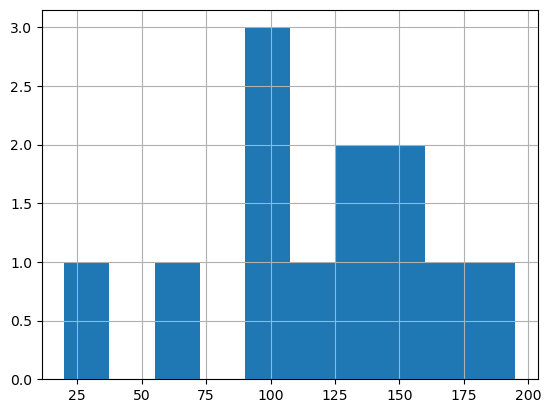

In [25]:
batch_sums.hist()

### Inspect batch size distribution

These inspection cells are optional but useful for understanding how the batching logic behaved on the current document.

- The first cell lists batch token totals from smallest to largest.
- The second cell inspects the smallest batch directly.

This is especially helpful when a document produces one or more undersized batches. In many cases, a small batch is not an error; it may simply reflect a short structural transition such as a legend, heading, or brief introductory paragraph occurring between larger sections.

For this example, the smallest batch is acceptable because it contains short context-setting elements rather than an unexpectedly fragmented content block.

In [26]:
# Inspect batch token totals from smallest to largest
batch_sums = elements_df.groupby("batch_number")["tokens"].sum()
batch_sums_sorted = batch_sums.sort_values(ascending=True)

print("Batch token totals (ascending):")
print(batch_sums_sorted.to_list())

Batch token totals (ascending):
[20, 67, 91, 96, 100, 120, 126, 132, 149, 154, 162, 195]


In [27]:
# Inspect the smallest batch
batch_sums = elements_df.groupby("batch_number")["tokens"].sum()
smallest_batch_number = batch_sums.idxmin()

smallest_batch_rows = elements_df[elements_df["batch_number"] == smallest_batch_number]

print(f"Smallest batch number: {smallest_batch_number}")
print(f"Total tokens: {batch_sums.loc[smallest_batch_number]}")
display(
    smallest_batch_rows[
        ["element_number", "element_type", "word_style", "tokens", "text"]
    ]
)

Smallest batch number: 10
Total tokens: 20


,element_number,element_type,word_style,tokens,text
24,25,paragraph,body,20,The Bible is **numbered** so that it is easy t...


In [28]:
# Inspect the largest extracted element by token count
elements_df.loc[elements_df["tokens"].idxmax()]

element_number                                                   26
element_type                                              paragraph
word_style                                                     body
text              Most of the books are divided into **chapters*...
element_id                                             a1347720f899
tokens                                                          195
batch_number                                                     11
Name: 25, dtype: object

In [29]:
largest_idx = elements_df["tokens"].idxmax()
display(elements_df.loc[[largest_idx], ["element_number", "element_type", "word_style", "tokens", "text"]])

,element_number,element_type,word_style,tokens,text
25,26,paragraph,body,195,Most of the books are divided into **chapters*...


In [30]:
# Spot-check one extracted row in DataFrame form
elements_df.iloc[6:7]

,element_number,element_type,word_style,text,element_id,tokens,batch_number
6,7,paragraph,h2,The Non-Sequential Reading Approach,44e085da6da8,6,3


In [31]:
# Spot-check the same element in raw dictionary form
elements[6]

{'element_number': 7,
 'element_type': 'paragraph',
 'word_style': 'h2',
 'text': 'The Non-Sequential Reading Approach',
 'element_id': '44e085da6da8',
 'tokens': 6,
 'batch_number': 3}

### Save elements schema to json for primary translation step

In [32]:
from importlib import reload
import workflow_helpers

workflow_helpers = reload(workflow_helpers)

metadata = workflow_helpers.build_workflow_metadata(
    stage=workflow_helpers.WORKFLOW_STAGES["batched"],
    docxfilename=docxfilename,
    source_language=source_language,
    target_language=None,
    primary_model_name=None,
    evaluation_model_name=None,
    fallback_model_name=None,
    primary_system_message=None,
    evaluation_system_message=None,
    fallback_system_message=None,
)

checkpoint_path = workflow_helpers.save_elements_checkpoint(
    elements=elements,
    base_filename=workflow_helpers.WORKFLOW_STAGES["batched"],
    metadata=metadata,
)

print(f"Checkpoint saved to: {checkpoint_path}")
print("Metadata saved:")
print(metadata)

Checkpoint saved to: checkpoints\elements_batched_20260411_1519.json
Metadata saved:
{'stage': 'elements_batched', 'docxfilename': 'custom_word_styles_example.docx', 'source_language': 'English', 'target_language': None, 'primary_model_name': None, 'evaluation_model_name': None, 'fallback_model_name': None, 'primary_system_message': None, 'evaluation_system_message': None, 'fallback_system_message': None}


In [33]:
import json

with open(checkpoint_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Top-level type:", type(data).__name__)
print("Keys:", list(data.keys()) if isinstance(data, dict) else None)
print("Metadata:", data.get("metadata") if isinstance(data, dict) else None)
print("First element:", data["elements"][0] if isinstance(data, dict) and data.get("elements") else None)

Top-level type: dict
Keys: ['metadata', 'elements']
Metadata: {'stage': 'elements_batched', 'docxfilename': 'custom_word_styles_example.docx', 'source_language': 'English', 'target_language': None, 'primary_model_name': None, 'evaluation_model_name': None, 'fallback_model_name': None, 'primary_system_message': None, 'evaluation_system_message': None, 'fallback_system_message': None}
First element: {'element_number': 1, 'element_type': 'paragraph', 'word_style': 'h1', 'text': 'Introduction', 'element_id': '8633e724fc99', 'tokens': 1, 'batch_number': 1}


## Notebook checkpoint and handoff

This notebook prepared a styled Word document for downstream LLM translation by completing the following steps:

- verified the input DOCX file path
- inspected paragraph styles and inline formatting
- extracted main-body paragraph elements
- appended footnote content to the extracted element package
- applied light text normalization during extraction to preserve readable prose for downstream translation
- counted tokens for each element
- assigned batch numbers for grouped downstream processing
- saved the resulting element state to a timestamped JSON checkpoint together with workflow metadata

### Output of this notebook
The main output is a timestamped JSON checkpoint containing:

- a top-level `metadata` block
- an `elements` list containing the extracted elements with token counts and batch assignments

This file is intended to be used as input for the next notebook.

### Metadata saved at this stage
The checkpoint metadata currently records:

- `stage = elements_batched`
- `source_language`
- placeholder fields for `target_language`, `primary_model_name`, `evaluation_model_name`, and `fallback_model_name`, which remain `None` at this stage

### Scope of this notebook
This notebook focuses on document inspection, extraction, token analysis, batching, and checkpoint creation.

At this stage:

- tables are currently ignored; this workflow extracts paragraph-based content only and does not package table cell content
- blank paragraphs are intentionally skipped
- image-only paragraphs are intentionally skipped from the extracted package
- footnotes are appended after main-body paragraph extraction
- non-breaking spaces are normalized during extraction
- aggressive punctuation escaping has been removed so extracted prose remains readable in downstream JSON state
- batching parameters are heuristic and may be adjusted depending on document size and structure

### Next step
The next notebook will load the checkpoint JSON, apply the full workflow schema, define the target language and primary model metadata, and perform the primary translation workflow on the extracted batches.

Go to: `1_primary_translation.ipynb`